## Mount Google Drive
This cell mounts your Google Drive to the Colab environment, allowing access to files stored in your Drive.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

## Import Libraries
This cell imports necessary Python libraries for numerical operations (`numpy`), plotting (`matplotlib.pyplot` and `matplotlib.lines.Line2D`), and loading Keras models (`tensorflow.keras.models`).

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from tensorflow.keras.models import load_model

## Define Model Paths
This cell creates a dictionary `model_dict` that maps model names to their respective file paths on Google Drive. These paths point to pre-trained segmentation models.

In [ ]:
model_dict = {
    "AE-UVNet": "your/model/path/AE-UVNet.hdf5",

    "VNet": "your/model/path/VNet.hdf5",
    "VNet+AE": "your/model/path/VNet+AE.hdf5",
    "UNet":"your/model/path/UNet.hdf5",
    "UNet+AE":"your/model/path/UNet+AE.hdf5",
}

## Segmentation Visualization Utilities
This cell defines a comprehensive set of utility functions for medical image segmentation visualization. It includes functions for:
- **Normalization**: Scaling image slices to a standard range.
- **Rotation**: Rotating 2D arrays.
- **Mask Remapping**: Standardizing segmentation labels (e.g., BraTS labels).
- **Layout Inference**: Standardizing image and mask dimensions.
- **Slice Picking**: Automatically selecting a tumor-centric slice.
- **Prediction Processing**: Converting model outputs to label maps.
- **Region Extraction**: Getting specific tumor regions (WT, TC, ET) from masks.
- **Color Mapping**: Defining consistent colors for different tumor regions.
- **Drawing Helpers**: Functions to set up plot axes, show original images, and overlay segmentation regions with contours.
- **Main Visualization Function**: `visualize_single_case_modality_region_table_with_legend` to generate a detailed table-like visualization comparing ground truth and multiple model predictions across different modalities and tumor regions.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from tensorflow.keras.models import load_model


# =========================
# 1. Utils
# =========================
def normalize_slice(img2d):
    img2d = img2d.astype(np.float32)
    mn, mx = img2d.min(), img2d.max()
    return (img2d - mn) / (mx - mn + 1e-6)


def rotate_2d(arr2d, k=1):
    """
    Uniformly rotate 90 degrees
    k=1 -> 90 degrees counter-clockwise
    k=2 -> 180 degrees
    k=3 -> 270 degrees
    """
    return np.rot90(arr2d, k=k)


def remap_mask_if_needed(mask):
    """
    Standardize labels to 0/1/2/3

    If original labels are 0/1/2/3, return directly.
    If original labels are common BraTS 0/1/2/4, then map to:
        1 -> 1   (NCR/NET)
        2 -> 2   (ED)
        4 -> 3   (ET)
    """
    mask = np.asarray(mask).copy()
    uniq = np.unique(mask)

    if set(uniq).issubset({0, 1, 2, 3}):
        return mask.astype(np.uint8)

    out = np.zeros_like(mask, dtype=np.uint8)
    out[mask == 1] = 1
    out[mask == 2] = 2
    out[mask == 3] = 3
    out[mask == 4] = 3
    return out.astype(np.uint8)


def infer_volume_layout(image, mask):
    """
    Standardize to:
      image -> (H, W, Z, C)
      mask  -> (H, W, Z)

    Supports:
      image: (H, W, Z, C) or (Z, H, W, C)
      mask : (H, W, Z) / (Z, H, W) / one-hot
    """
    image = np.asarray(image)
    mask = np.asarray(mask)

    if image.ndim != 4:
        raise ValueError(f"Image should be 4D, but received {image.shape}")

    if mask.ndim not in [3, 4]:
        raise ValueError(f"Mask should be 3D or 4D, but received {mask.shape}")

    if mask.ndim == 4:
        if mask.shape[-1] > 1:
            mask = np.argmax(mask, axis=-1)
        else:
            mask = mask[..., 0]

    if image.shape[:3] == mask.shape:
        return image, mask

    if image.shape[1:4] == mask.shape:
        image = np.transpose(image, (1, 2, 0, 3))
        return image, mask

    mask_t = np.transpose(mask, (1, 2, 0))
    if image.shape[:3] == mask_t.shape:
        return image, mask_t

    if image.shape[1:4] == mask_t.shape:
        image = np.transpose(image, (1, 2, 0, 3))
        return image, mask_t

    raise ValueError(f"Cannot align image {image.shape} and mask {mask.shape}")


def pick_center_slice(mask3d):
    """
    Automatically select the tumor center slice based on GT, mask3d shape is (H, W, Z)
    """
    z_list = np.where(np.any(mask3d > 0, axis=(0, 1)))[0]
    if len(z_list) == 0:
        return mask3d.shape[2] // 2
    return int(np.median(z_list))


def maybe_to_label_map(pred):
    """
    Convert model output to label map:
      (H, W, Z)    -> return directly
      (H, W, Z, K) -> argmax
    """
    pred = np.asarray(pred)

    if pred.ndim == 3:
        return pred.astype(np.uint8)

    if pred.ndim == 4:
        return np.argmax(pred, axis=-1).astype(np.uint8)

    raise ValueError(f"Unsupported prediction output shape: {pred.shape}")


def predict_one_case(model, image):
    """
    Default whole-volume prediction:
      image: (H, W, Z, C)
      model input: (1, H, W, Z, C)
    """
    x = np.expand_dims(image, axis=0)
    pred = model.predict(x, verbose=0)
    pred = np.squeeze(pred, axis=0)
    pred = maybe_to_label_map(pred)
    pred = remap_mask_if_needed(pred)
    return pred


# =========================
# 2. Region extraction + color
# =========================
def get_region_mask(mask2d, region_name):
    """
    Extract WT / TC / ET from remapped labels
    Default semantics:
        1 = NCR/NET
        2 = ED
        3 = ET

    WT = 1|2|3
    TC = 1|3
    ET = 3
    """
    mask2d = remap_mask_if_needed(mask2d)

    if region_name == "WT":
        region_mask = (mask2d > 0).astype(np.uint8)
    elif region_name == "TC":
        region_mask = np.logical_or(mask2d == 1, mask2d == 3).astype(np.uint8)
    elif region_name == "ET":
        region_mask = (mask2d == 3).astype(np.uint8)
    else:
        raise ValueError("region_name must be WT / TC / ET")

    return region_mask


def get_region_color_map():
    """
    Global unique color definition
    """
    return {
        "WT": (0.0, 1.0, 0.0),      # green
        "TC": (0.25, 0.45, 1.0),    # blue
        "ET": (1.0, 0.2, 0.2),      # red
    }


def get_region_color(region_name):
    color_map = get_region_color_map()
    if region_name not in color_map:
        raise ValueError("region_name must be WT / TC / ET")
    return color_map[region_name]


# =========================
# 3. Drawing helpers
# =========================
def setup_ax(ax):
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_facecolor("black")
    for spine in ax.spines.values():
        spine.set_visible(False)


def show_original_image(ax, img2d, rotate_k=1):
    img2d = normalize_slice(img2d)
    img2d = rotate_2d(img2d, k=rotate_k)
    ax.imshow(img2d, cmap="gray", interpolation="bilinear")
    setup_ax(ax)


def overlay_region(ax, img2d, mask2d, region_name, alpha=0.45, add_contour=True, rotate_k=1):
    """
    Overlay a single region of interest (ROI) on a grayscale MRI
    """
    img2d = normalize_slice(img2d)
    region_mask = get_region_mask(mask2d, region_name)
    color = get_region_color(region_name)

    img2d = rotate_2d(img2d, k=rotate_k)
    region_mask = rotate_2d(region_mask, k=rotate_k)

    ax.imshow(img2d, cmap="gray", interpolation="bilinear")

    overlay = np.zeros((*region_mask.shape, 4), dtype=np.float32)
    overlay[region_mask > 0] = [color[0], color[1], color[2], alpha]
    ax.imshow(overlay, interpolation="nearest")

    if add_contour and np.any(region_mask > 0):
        ax.contour(
            region_mask.astype(np.uint8),
            levels=[0.5],
            linewidths=1.0,
            colors=[(1, 1, 1, 0.85)]
        )

    setup_ax(ax)


def overlay_wt_tc_et(ax, img2d, mask2d, alpha=0.45, add_contour=True, rotate_k=1):
    """
    Overlay WT / TC / ET simultaneously on one image
    Colors are consistent with overlay_region
    """
    img2d = normalize_slice(img2d)
    mask2d = remap_mask_if_needed(mask2d)

    wt_mask = get_region_mask(mask2d, "WT").astype(bool)
    tc_mask = get_region_mask(mask2d, "TC").astype(bool)
    et_mask = get_region_mask(mask2d, "ET").astype(bool)

    img2d = rotate_2d(img2d, k=rotate_k)
    wt_mask = rotate_2d(wt_mask, k=rotate_k)
    tc_mask = rotate_2d(tc_mask, k=rotate_k)
    et_mask = rotate_2d(et_mask, k=rotate_k)

    color_map = get_region_color_map()
    wt_color = color_map["WT"]
    tc_color = color_map["TC"]
    et_color = color_map["ET"]

    ax.imshow(img2d, cmap="gray", interpolation="bilinear")

    overlay = np.zeros((*img2d.shape, 4), dtype=np.float32)
    overlay[wt_mask] = [wt_color[0], wt_color[1], wt_color[2], alpha]
    overlay[tc_mask] = [tc_color[0], tc_color[1], tc_color[2], alpha]
    overlay[et_mask] = [et_color[0], et_color[1], et_color[2], alpha]

    ax.imshow(overlay, interpolation="nearest")

    if add_contour:
        for region_mask in [wt_mask, tc_mask, et_mask]:
            if np.any(region_mask):
                ax.contour(
                    region_mask.astype(np.uint8),
                    levels=[0.5],
                    linewidths=1.0,
                    colors=[(1, 1, 1, 0.85)]
                )

    setup_ax(ax)


# =========================
# 4. Main function
# =========================
def visualize_single_case_modality_region_table_with_legend(
    model_dict,
    image_path,
    mask_path,
    modality_dict=None,
    modality_region_map=None,
    z_idx=None,
    alpha=0.45,
    overlay_alpha=0.45,
    add_contour=True,
    rotate_k=1,
    original_bg_modality="FLAIR",
    figsize=(21, 12),
    save_path=None
):
    """
    Effect (move Original Image to one column instead of one row):

                    Original   GT      UNET    UNET+T   VNET   VNET+T   UVNET
        FLAIR       image      WT      WT      WT       WT     WT       WT
        T1ce        image      ET      ET      ET       ET     ET       ET
        T2          image      TC      TC      TC       TC     TC       TC
        WT/TC/ET    image      overlay overlay overlay  overlay overlay  overlay

    Key points:
      - FLAIR row only shows WT
      - T1ce row only shows ET
      - T2 row only shows TC
      - The last row shows WT / TC / ET overlaid simultaneously
      - Original Image as the first column
      - The entire display is rotated 90 degrees uniformly
    """
    image = np.load(image_path)
    mask = np.load(mask_path)

    image, mask = infer_volume_layout(image, mask)
    mask = remap_mask_if_needed(mask)

    _, _, _, C = image.shape

    if modality_dict is None:
        modality_dict = {
            "FLAIR": 0,
            "T1ce": 1,
            "T2": 2,
        }

    if modality_region_map is None:
        modality_region_map = {
            "FLAIR": "WT",
            "T1ce": "ET",
            "T2": "TC",
        }

    for mod_name, ch in modality_dict.items():
        if ch < 0 or ch >= C:
            raise ValueError(f"Channel index {ch} for {mod_name} is out of range, current image shape={image.shape}")

    if original_bg_modality not in modality_dict:
        raise ValueError(f"original_bg_modality={original_bg_modality} is not in modality_dict")

    if z_idx is None:
        z_idx = pick_center_slice(mask)

    preds = {}
    for model_name, model_path in model_dict.items():
        print(f"Loading model: {model_name}")
        model = load_model(model_path, compile=False)

        print(f"Predicting with {model_name}")
        preds[model_name] = predict_one_case(model, image)

    row_names = list(modality_dict.keys())                      # FLAIR, T1ce, T2
    col_names = ["Original", "GT"] + list(model_dict.keys())   # Add one column for Original

    n_mod_rows = len(row_names)
    n_cols = len(col_names)
    n_rows_total = n_mod_rows + 1   # +1 for WT/TC/ET overlay

    fig, axes = plt.subplots(n_rows_total, n_cols, figsize=figsize, facecolor="black")

    if n_rows_total == 1 and n_cols == 1:
        axes = np.array([[axes]])
    elif n_rows_total == 1:
        axes = np.expand_dims(axes, axis=0)
    elif n_cols == 1:
        axes = np.expand_dims(axes, axis=1)

    # Top column titles
    for c, name in enumerate(col_names):
        axes[0, c].set_title(
            name,
            color="white",
            fontsize=20,
            pad=10,
            fontweight="bold"
        )

    # Three modality rows
    for r, mod_name in enumerate(row_names):
        mod_ch = modality_dict[mod_name]
        region_name = modality_region_map[mod_name]
        img2d = image[:, :, z_idx, mod_ch]

        # Original
        show_original_image(
            axes[r, 0],
            img2d,
            rotate_k=rotate_k
        )

        # GT
        overlay_region(
            axes[r, 1],
            img2d,
            mask[:, :, z_idx],
            region_name=region_name,
            alpha=alpha,
            add_contour=add_contour,
            rotate_k=rotate_k
        )

        # Models
        for c, model_name in enumerate(model_dict.keys(), start=2):
            overlay_region(
                axes[r, c],
                img2d,
                preds[model_name][:, :, z_idx],
                region_name=region_name,
                alpha=alpha,
                add_contour=add_contour,
                rotate_k=rotate_k
            )

    # WT / TC / ET overlay row
    overlay_row = n_mod_rows
    bg_ch = modality_dict[original_bg_modality]
    bg_img2d = image[:, :, z_idx, bg_ch]

    # Original
    show_original_image(
        axes[overlay_row, 0],
        bg_img2d,
        rotate_k=rotate_k
    )

    # GT
    overlay_wt_tc_et(
        axes[overlay_row, 1],
        bg_img2d,
        mask[:, :, z_idx],
        alpha=overlay_alpha,
        add_contour=add_contour,
        rotate_k=rotate_k
    )

    # Models
    for c, model_name in enumerate(model_dict.keys(), start=2):
        overlay_wt_tc_et(
            axes[overlay_row, c],
            bg_img2d,
            preds[model_name][:, :, z_idx],
            alpha=overlay_alpha,
            add_contour=add_contour,
            rotate_k=rotate_k
        )

    # Left labels
    left_label_map = {
        "FLAIR": "FLAIR\n(WT)",
        "T1ce": "T1ce\n(ET)",
        "T2": "T2\n(TC)",
    }

    for r, mod_name in enumerate(row_names):
        axes[r, 0].text(
            -0.16,
            0.5,
            left_label_map.get(mod_name, mod_name),
            transform=axes[r, 0].transAxes,
            ha="right",
            va="center",
            fontsize=20,
            color="white",
            fontweight="bold"
        )

    axes[overlay_row, 0].text(
        -0.16,
        0.5,
        "WT/TC/ET",
        transform=axes[overlay_row, 0].transAxes,
        ha="right",
        va="center",
        fontsize=20,
        color="white",
        fontweight="bold"
    )

    # Layout
    plt.subplots_adjust(
        left=0.14,
        right=0.995,
        top=0.93,
        bottom=0.03,
        wspace=0.02,
        hspace=0.08
    )

    # Vertical lines
    for c in range(1, n_cols):
        x = axes[0, c - 1].get_position().x1
        y0 = axes[-1, 0].get_position().y0
        y1 = axes[0, 0].get_position().y1
        fig.add_artist(Line2D(
            [x, x], [y0, y1],
            transform=fig.transFigure,
            color="white",
            linewidth=1.0,
            alpha=0.9
        ))

    # Horizontal lines
    for r in range(1, n_rows_total):
        y = axes[r - 1, 0].get_position().y0
        x0 = axes[0, 0].get_position().x0
        x1 = axes[0, -1].get_position().x1
        fig.add_artist(Line2D(
            [x0, x1], [y, y],
            transform=fig.transFigure,
            color="white",
            linewidth=0.8,
            alpha=0.5
        ))

    # Outer frame
    left = axes[0, 0].get_position().x0
    right = axes[0, -1].get_position().x1
    top = axes[0, 0].get_position().y1
    bottom = axes[-1, 0].get_position().y0

    fig.add_artist(Line2D([left, right], [top, top], transform=fig.transFigure, color="white", linewidth=1.0))
    fig.add_artist(Line2D([left, right], [bottom, bottom], transform=fig.transFigure, color="white", linewidth=1.0))
    fig.add_artist(Line2D([left, left], [bottom, top], transform=fig.transFigure, color="white", linewidth=1.0))
    fig.add_artist(Line2D([right, right], [bottom, top], transform=fig.transFigure, color="white", linewidth=1.0))

    if save_path:
        plt.savefig(
            save_path,
            dpi=300,
            bbox_inches="tight",
            pad_inches=0.03,
            facecolor="black"
        )
        print("Saved:", save_path)

    plt.show()

## Generate Visualization Table
This cell calls the `visualize_single_case_modality_region_table_with_legend` function to generate a comprehensive visualization of segmentation results. It uses the `model_dict` defined earlier and specifies paths to an image and its corresponding mask. The visualization is saved as 'visualisation.png'.

Loading model: AE-UVNet
Predicting with AE-UVNet
Loading model: VNet
Predicting with VNet
Loading model: VNet+AE
Predicting with VNet+AE
Loading model: UNet
Predicting with UNet
Loading model: UNet+AE
Predicting with UNet+AE


Saved: visualisation.png


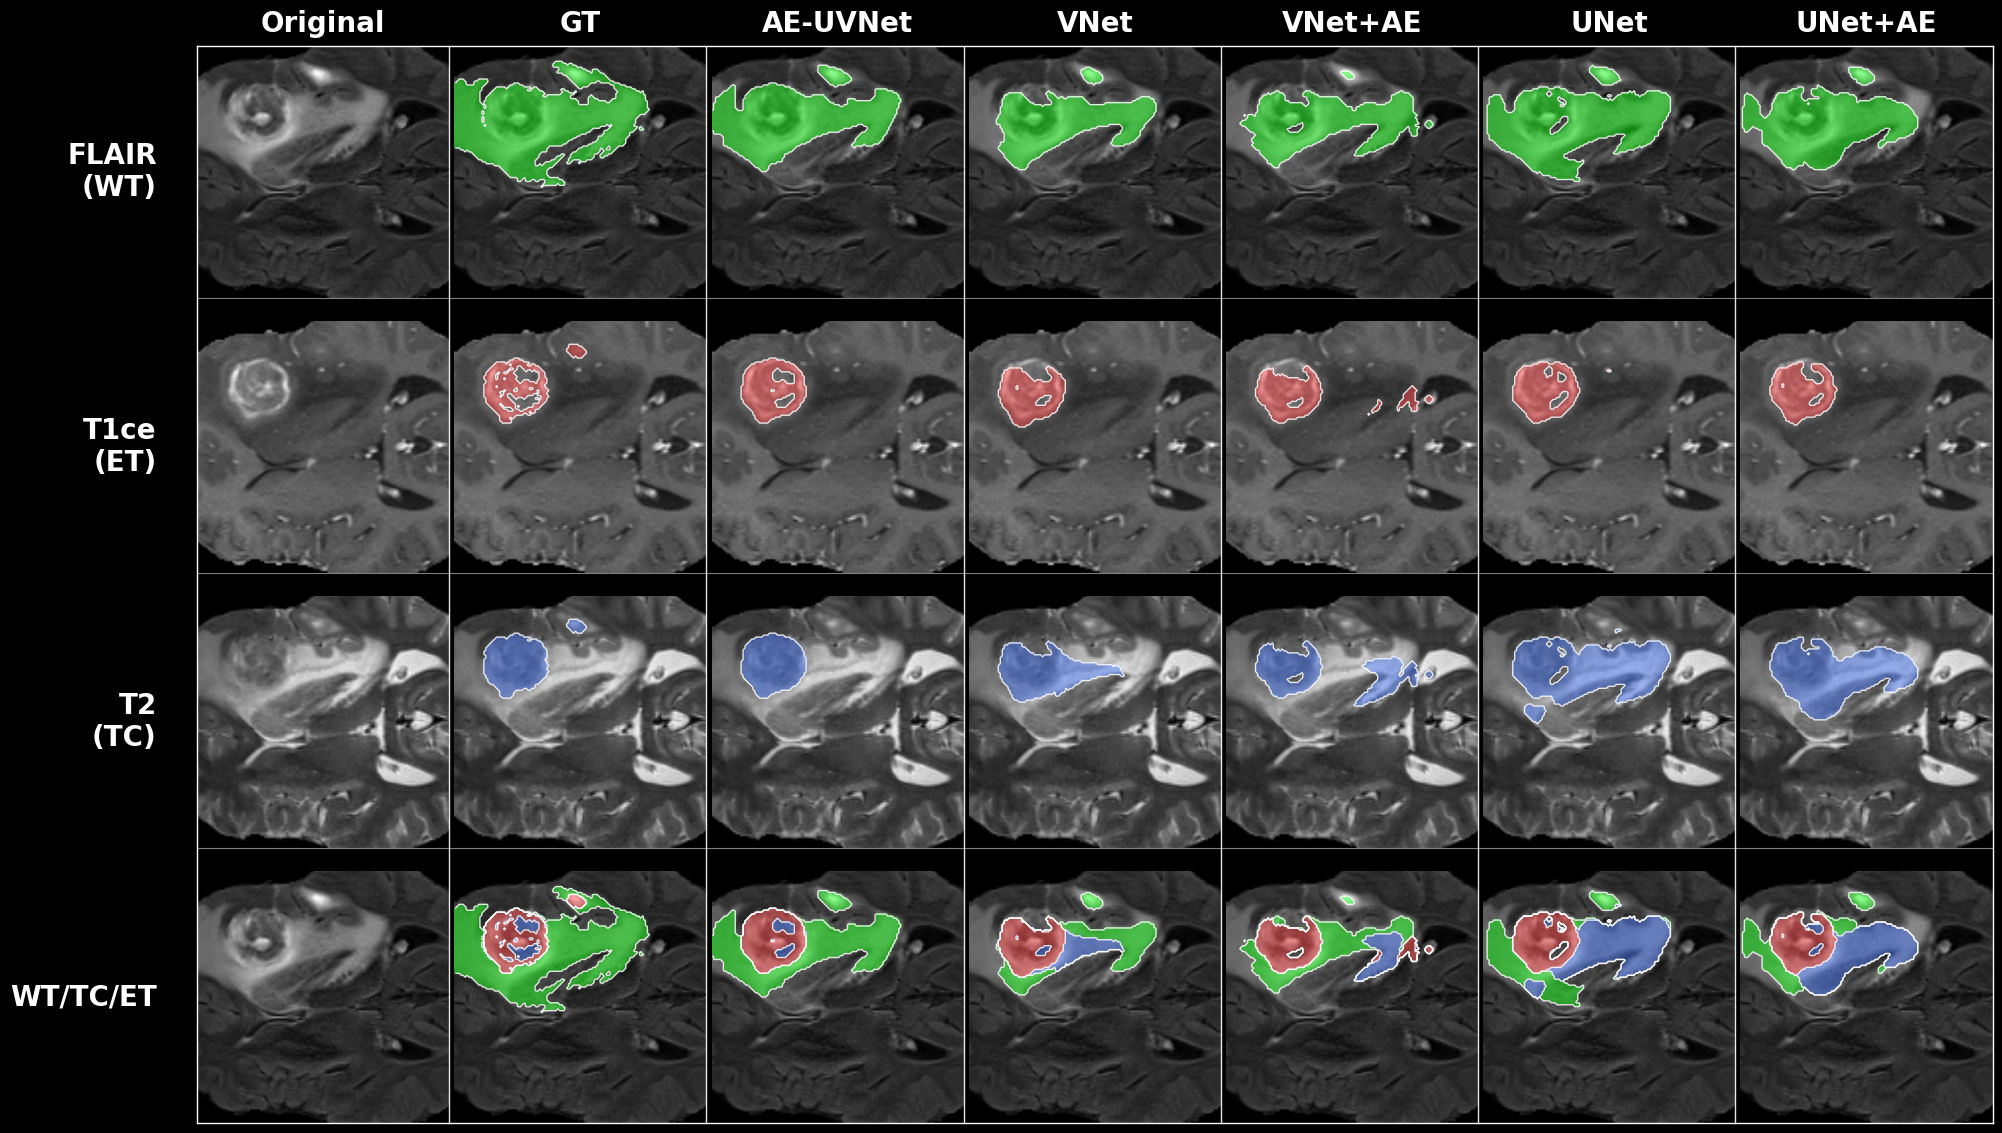

In [ ]:
visualize_single_case_modality_region_table_with_legend(
    model_dict=model_dict,
    rotate_k=0,
    image_path="/your/image/path/BraTS2020_TrainingData/input_data_3channels/images/image_25.npy",
    mask_path="/your/mask/path/BraTS2020_TrainingData/input_data_3channels/masks/mask_25.npy",
    save_path="visualisation.png"
)

## Single Prediction Overlay Utilities
This cell defines a simpler set of utility functions focused on visualizing a single model's prediction overlay. It includes functions for:
- **Basic Utilities**: `normalize_slice`, `remap_mask`, `infer_volume_layout`, `pick_center_slice`, `maybe_to_label_map`, and `predict_one_case`, similar to the previous cell but potentially streamlined for single-prediction use cases.
- **Overlay Display**: `overlay_wt_tc_et` to display whole tumor (WT), tumor core (TC), and enhancing tumor (ET) regions overlaid on a 2D image slice.
- **Main Function**: `visualize_one_prediction_overlay` to take a model path, image path, and optional mask path to generate and display a single overlay visualization.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model


# =========================
# 1. Basic Utilities
# =========================
def normalize_slice(img2d):
    img2d = img2d.astype(np.float32)
    mn, mx = img2d.min(), img2d.max()
    return (img2d - mn) / (mx - mn + 1e-6)


def remap_mask(mask):
    """
    Standardize labels to 0/1/2/3
    If the original labels are 0/1/2/4, map them to:
        1 -> 1   (NCR/NET)
        2 -> 2   (ED)
        4 -> 3   (ET)
    """
    mask = np.asarray(mask)
    out = np.zeros_like(mask, dtype=np.uint8)
    out[mask == 1] = 1
    out[mask == 2] = 2
    out[mask == 3] = 3
    out[mask == 4] = 3
    return out


def infer_volume_layout(image, mask=None):
    """
    Standardize image to (H, W, Z, C)
    Supports:
      image: (H, W, Z, C) or (Z, H, W, C)
    """
    image = np.asarray(image)

    if image.ndim != 4:
        raise ValueError(f"Image must be 4D, but current shape={image.shape}")

    if mask is None:
        return image

    mask = np.asarray(mask)

    if mask.ndim == 4:
        if mask.shape[-1] > 1:
            mask = np.argmax(mask, axis=-1)
        else:
            mask = mask[..., 0]

    if image.shape[:3] == mask.shape:
        return image, mask

    if image.shape[1:4] == mask.shape:
        return np.transpose(image, (1, 2, 0, 3)), mask

    mask_t = np.transpose(mask, (1, 2, 0))
    if image.shape[:3] == mask_t.shape:
        return image, mask_t

    if image.shape[1:4] == mask_t.shape:
        return np.transpose(image, (1, 2, 0, 3)), mask_t

    raise ValueError(f"Cannot align image {image.shape} and mask {mask.shape}")


def pick_center_slice(mask3d):
    """Automatically selects the center slice based on the tumor region"""
    z_list = np.where(np.any(mask3d > 0, axis=(0, 1)))[0]
    if len(z_list) == 0:
        return mask3d.shape[2] // 2
    return int(np.median(z_list))


def maybe_to_label_map(pred):
    """
    Convert model output to label map
      (H, W, Z)    -> return directly
      (H, W, Z, K) -> argmax
    """
    pred = np.asarray(pred)

    if pred.ndim == 3:
        return pred.astype(np.uint8)
    elif pred.ndim == 4:
        return np.argmax(pred, axis=-1).astype(np.uint8)
    else:
        raise ValueError(f"Unsupported prediction output shape: {pred.shape}")


def predict_one_case(model, image):
    """
    whole-volume prediction
    image: (H, W, Z, C)
    """
    x = np.expand_dims(image, axis=0)   # (1, H, W, Z, C)
    pred = model.predict(x, verbose=0)
    pred = np.squeeze(pred, axis=0)
    pred = maybe_to_label_map(pred)
    pred = remap_mask(pred)
    return pred


# =========================
# 2. Overlay Display
# =========================
def overlay_wt_tc_et(img2d, mask2d, alpha=0.45, rotate_k=1):
    """
    Display WT / TC / ET on one image
    Label semantics:
      1 = NCR/NET
      2 = ED
      3 = ET

    WT = 1|2|3  -> green
    TC = 1|3    -> blue
    ET = 3      -> red
    """
    img2d = normalize_slice(img2d)
    mask2d = remap_mask(mask2d)

    wt = (mask2d > 0)
    tc = np.logical_or(mask2d == 1, mask2d == 3)
    et = (mask2d == 3)

    img2d = np.rot90(img2d, k=rotate_k)
    wt = np.rot90(wt, k=rotate_k)
    tc = np.rot90(tc, k=rotate_k)
    et = np.rot90(et, k=rotate_k)

    overlay = np.zeros((*img2d.shape, 4), dtype=np.float32)
    overlay[wt] = [0.0, 1.0, 0.0, alpha]      # WT: green
    overlay[tc] = [0.25, 0.45, 1.0, alpha]    # TC: blue
    overlay[et] = [1.0, 0.2, 0.2, alpha]      # ET: red

    plt.figure(figsize=(6, 6), facecolor="black")
    plt.imshow(img2d, cmap="gray")
    plt.imshow(overlay)
    plt.axis("off")
    plt.tight_layout()
    plt.show()


# =========================
# 3. Main function: Output a single prediction overlay
# =========================
def visualize_one_prediction_overlay(
    model_path,
    image_path,
    mask_path=None,
    modality_idx=0,   # e.g., FLAIR=0, T1ce=1, T2=2
    z_idx=None,
    rotate_k=1,
    alpha=0.45
):
    image = np.load(image_path)

    if mask_path is not None:
        mask = np.load(mask_path)
        image, mask = infer_volume_layout(image, mask)
        mask = remap_mask(mask)
    else:
        image = infer_volume_layout(image)
        mask = None

    model = load_model(model_path, compile=False)
    pred = predict_one_case(model, image)

    if z_idx is None:
        if mask is not None:
            z_idx = pick_center_slice(mask)
        else:
            z_idx = pred.shape[2] // 2

    img2d = image[:, :, z_idx, modality_idx]
    pred2d = pred[:, :, z_idx]

    overlay_wt_tc_et(img2d, pred2d, alpha=alpha, rotate_k=rotate_k)

## Visualize One Prediction Overlay
This cell calls the `visualize_one_prediction_overlay` function to display the segmentation prediction from a single model overlaid on an image slice. It specifies the model path, image path, an optional mask path (used for automatic center slice selection), and the modality index (FLAIR in this case).

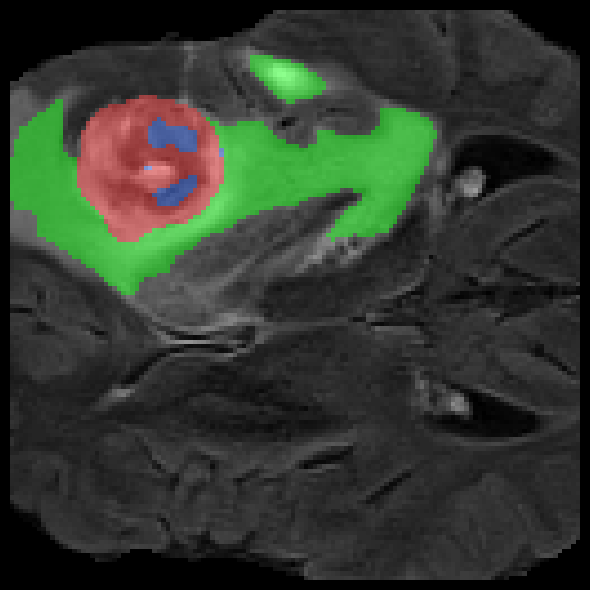

In [ ]:
visualize_one_prediction_overlay(
    model_path="your/model/path/AE-UVNet.hdf5",
    image_path="/your/image/path/BraTS2020_TrainingData/input_data_3channels/images/image_25.npy",
    mask_path="/your/mask/path/BraTS2020_TrainingData/input_data_3channels/masks/mask_25.npy",  
    modality_idx=0,         # FLAIR
    rotate_k=0,
    alpha=0.45
)